# Credit Card Recommendation System
### Improved Model: XGBoost with Rich Feature Engineering

In [1]:
# Install dependencies
import subprocess
subprocess.run(['pip', 'install', 'pandas', 'scikit-learn', 'numpy', 'openpyxl', 'xgboost', 'matplotlib', 'seaborn', '--quiet'], capture_output=True)
print('All packages ready.')

All packages ready.


In [2]:
import pandas as pd
import numpy as np
import json
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load Data

In [3]:
# Load datasets
customer_df = pd.read_csv('customers_updated2.csv')
transaction_df = pd.read_excel('final_transact.xlsx')

print(f"Customers: {customer_df.shape[0]} rows, {customer_df.shape[1]} columns")
print(f"Transactions: {transaction_df.shape[0]} rows, {transaction_df.shape[1]} columns")
print()
print(customer_df.head(3))
print()
print(transaction_df.head(3))

Customers: 300 rows, 13 columns
Transactions: 300000 rows, 7 columns

             Full Name  Account Number  CIBIL Score  \
0          Renee Dayal    794843871722          367   
1          Bhavin Toor    963450436285          601   
2  Nitara Venkataraman    314939397126          678   

                                   Address           State     City Country  \
0  138, Dugar Path, Rajpur Sonarpur-590544   Uttar Pradesh  Lucknow   India   
1              368, Chana, Amravati-727268  Madhya Pradesh   Indore   India   
2        10/81, Dhar Road, Dehradun-400493       Rajasthan   Jaipur   India   

   Mobile Number PAN Card Number           Occupation  \
0     6990527801      UTVQH01965           Pharmacist   
1     6598772407      QWYJQ44260  Marketing Executive   
2     6188847212      LWOIF64245               Lawyer   

            Branch of the Bank  Annual Income (in Rs)  Gender  
0  Union Bank - Lucknow Branch                 321958  Female  
1   Union Bank - Indore Branch     

## 2. Data Preprocessing

In [4]:
# Clean transaction details — remove hyphens
transaction_df['Transaction Details'] = transaction_df['Transaction Details'].str.replace('-', ' ', regex=False)

# Monthly income
customer_df['Monthly_Income'] = customer_df['Annual Income (in Rs)'] / 12

# Credit limit based on CIBIL Score tier
def calculate_credit_limit(row):
    if row['CIBIL Score'] >= 800:
        multiplier = 5
    elif row['CIBIL Score'] >= 700:
        multiplier = 3
    elif row['CIBIL Score'] >= 600:
        multiplier = 2
    else:
        multiplier = 1
    return row['Monthly_Income'] * multiplier

customer_df['Credit_Limit'] = customer_df.apply(calculate_credit_limit, axis=1)

# CIBIL score band — ordinal feature (better than raw score for tree models)
def cibil_band(score):
    if score >= 800: return 4
    elif score >= 750: return 3
    elif score >= 700: return 2
    elif score >= 650: return 1
    else: return 0

customer_df['CIBIL_Band'] = customer_df['CIBIL Score'].apply(cibil_band)

# Encode categorical columns
le_occ = LabelEncoder()
le_gen = LabelEncoder()
customer_df['Occupation_enc'] = le_occ.fit_transform(customer_df['Occupation'])
customer_df['Gender_enc'] = le_gen.fit_transform(customer_df['Gender'])

print("Customer preprocessing done.")
print(customer_df[['Full Name','Monthly_Income','Credit_Limit','CIBIL_Band']].head())

Customer preprocessing done.
             Full Name  Monthly_Income   Credit_Limit  CIBIL_Band
0          Renee Dayal    26829.833333   26829.833333           0
1          Bhavin Toor    72596.250000  145192.500000           0
2  Nitara Venkataraman    27661.000000   55322.000000           1
3           Purab Lata   134534.500000  134534.500000           0
4           Nitara Lad    38264.833333  191324.166667           4


## 3. Transaction Categorization

In [5]:
def categorize_transaction(transaction):
    """Categorize a transaction string into a spending category."""
    t = transaction.lower()

    if any(k in t for k in ['restaurant','dining','zomato','swiggy','starbucks','kfc','pizza hut','burger king']):
        return 'Dining'
    elif any(k in t for k in ['travel','airbnb','hotel','makemytrip','uber','booking.com','expedia']):
        return 'Travel'
    elif any(k in t for k in ['fuel','shell','hpcl','indianoil','tesla','chevron','exxon','bp']):
        return 'Fuel'
    elif any(k in t for k in ['shopping','zara','myntra','flipkart','amazon','costco','walmart','h&m','nike','adidas','target','gap','uniqlo']):
        return 'Shopping'
    elif any(k in t for k in ['grocery','bigbasket','grofers','dmart','whole foods','kroger']):
        return 'Grocery'
    elif any(k in t for k in ['subscription','netflix','spotify','apple music','prime video','hulu','disney+']):
        return 'Subscription'
    elif any(k in t for k in ['foreign','forex','usd','uk','germany','japan','usa','australia','canada','euro','singapore']):
        return 'Foreign'
    elif any(k in t for k in ['finance','paypal','bank transfer','credit card','debit card']):
        return 'Finance'
    elif any(k in t for k in ['social','facebook','twitter','instagram','snapchat','linkedin','tiktok']):
        return 'Social Media'
    elif any(k in t for k in ['health','hospital','pharmacy','clinic','medicines','insurance']):
        return 'Health'
    elif any(k in t for k in ['education','school','college','university','course','learning']):
        return 'Education'
    elif any(k in t for k in ['electricity','water','gas','internet','mobile','recharge','bill']):
        return 'Utility'
    elif 'mixed' in t:
        return 'Mixed'
    else:
        return 'Other'

transaction_df['Category'] = transaction_df['Transaction Details'].apply(categorize_transaction)
print("Category distribution:")
print(transaction_df['Category'].value_counts())

Category distribution:
Category
Other           113598
Foreign          59892
Shopping         52538
Fuel             15097
Travel           15043
Subscription     15023
Finance           7705
Dining            7566
Social Media      7466
Mixed             6072
Name: count, dtype: int64


## 4. Rich Feature Engineering (Key Improvement)

Instead of only summing withdrawals per category, we compute **three feature sets** per customer:
- **Total spend** per category (original feature)
- **Transaction frequency** per category (new — how often they use each category)
- **Average transaction size** per category (new — typical ticket size signals card suitability)

In [6]:
# Feature Set 1: Total spend per category (original)
spend_total = (
    transaction_df.groupby(['Account Number', 'Category'])['Withdrawal Amount']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

# Feature Set 2: Transaction frequency per category (NEW)
spend_freq = (
    transaction_df.groupby(['Account Number', 'Category'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
spend_freq.columns = ['Account Number'] + [f'{c}_count' for c in spend_freq.columns[1:]]

# Feature Set 3: Average transaction size per category (NEW)
spend_avg = (
    transaction_df.groupby(['Account Number', 'Category'])['Withdrawal Amount']
    .mean()
    .unstack(fill_value=0)
    .reset_index()
)
spend_avg.columns = ['Account Number'] + [f'{c}_avg' for c in spend_avg.columns[1:]]

# Merge everything together
data = (
    customer_df
    .merge(spend_total, on='Account Number', how='left')
    .merge(spend_freq,  on='Account Number', how='left')
    .merge(spend_avg,   on='Account Number', how='left')
)
data.fillna(0, inplace=True)

spend_cols  = [c for c in spend_total.columns if c != 'Account Number']
count_cols  = [c for c in data.columns if c.endswith('_count')]
avg_cols    = [c for c in data.columns if c.endswith('_avg')]

print(f"Total features available: {len(spend_cols) + len(count_cols) + len(avg_cols) + 5}")
print(f"Spend categories: {spend_cols}")

Total features available: 35
Spend categories: ['Dining', 'Finance', 'Foreign', 'Fuel', 'Mixed', 'Other', 'Shopping', 'Social Media', 'Subscription', 'Travel']


## 5. Rule-Based Card Assignment (Ground Truth Labels)

In [7]:
card_criteria = {
    'Union JCB Wellness Credit Card':  {'min_income': 25000, 'min_score': 700, 'categories': ['Dining', 'Shopping']},
    'RuPay Select Credit Card':        {'min_income': 25000, 'min_score': 720, 'categories': ['Travel', 'Dining']},
    'Union JCB Health Credit Card':    {'min_income': 30000, 'min_score': 700, 'categories': ['Dining', 'Shopping']},
    'Union UNI-CARBON Credit Card':    {'min_income': 50000, 'min_score': 700, 'categories': ['Fuel', 'Shopping']},
    'RuPay Platinum Credit Card':      {'min_income': 30000, 'min_score': 700, 'categories': ['Dining', 'Travel']},
    'VISA Signature Credit Card':      {'min_income': 75000, 'min_score': 750, 'categories': ['Travel', 'Shopping']},
    'VISA Platinum Credit Card':       {'min_income': 50000, 'min_score': 700, 'categories': ['Fuel', 'Dining']},
    'VISA Gold Credit Card':           {'min_income': 25000, 'min_score': 700, 'categories': ['Shopping', 'Dining']},
    'Divaa Credit Card':               {'min_income': 25000, 'min_score': 700, 'categories': ['Shopping', 'Dining']}
}

def recommend_cards(row):
    recommendations = []
    for card, criteria in card_criteria.items():
        if row['Monthly_Income'] < criteria['min_income']: continue
        if row['CIBIL Score']    < criteria['min_score']:  continue
        if not [cat for cat in criteria['categories'] if row.get(cat, 0) > 0]: continue
        recommendations.append(card)
    return recommendations if recommendations else ['No Card']

data['Recommended_Cards'] = data.apply(recommend_cards, axis=1)
data['Primary_Card']      = data['Recommended_Cards'].apply(lambda x: x[0])

print("Card distribution (primary recommendation):")
print(data['Primary_Card'].value_counts())

Card distribution (primary recommendation):
Primary_Card
No Card                           203
Union JCB Wellness Credit Card     97
Name: count, dtype: int64


## 6. Model Training — XGBoost Classifier

**Why XGBoost over Random Forest?**
- Gradient boosting builds trees sequentially, correcting previous errors — generally higher accuracy
- Built-in L1/L2 regularization (, ) prevents overfitting
- Handles class imbalance via 
- Faster inference, better feature importance via gain (not impurity like RF)
- Supports 5-fold stratified cross-validation out of the box

In [8]:
# Prepare features and labels
feature_cols = (
    ['Monthly_Income', 'CIBIL Score', 'CIBIL_Band', 'Credit_Limit', 'Occupation_enc', 'Gender_enc']
    + spend_cols + count_cols + avg_cols
)
X = data[feature_cols]

le_target = LabelEncoder()
y = le_target.fit_transform(data['Primary_Card'])

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# XGBoost model with tuned hyperparameters
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train, y_train, verbose=False)

# Evaluate
y_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

Test Accuracy: 1.0000 (100.00%)

Classification Report:
                                precision    recall  f1-score   support

                       No Card       1.00      1.00      1.00        41
Union JCB Wellness Credit Card       1.00      1.00      1.00        19

                      accuracy                           1.00        60
                     macro avg       1.00      1.00      1.00        60
                  weighted avg       1.00      1.00      1.00        60



## 7. Cross-Validation (5-Fold Stratified)

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
print("5-Fold Cross-Validation Results:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean:   {cv_scores.mean():.4f}")
print(f"  Std:    {cv_scores.std():.4f}")

stability = 'stable' if cv_scores.std() < 0.02 else 'variable'
print(f"\nModel is {stability} across folds (std={cv_scores.std():.4f})")

5-Fold Cross-Validation Results:
  Fold 1: 0.9667
  Fold 2: 1.0000
  Fold 3: 1.0000
  Fold 4: 1.0000
  Fold 5: 0.9833
  Mean:   0.9900
  Std:    0.0133

Model is stable across folds (std=0.0133)


## 8. Confusion Matrix

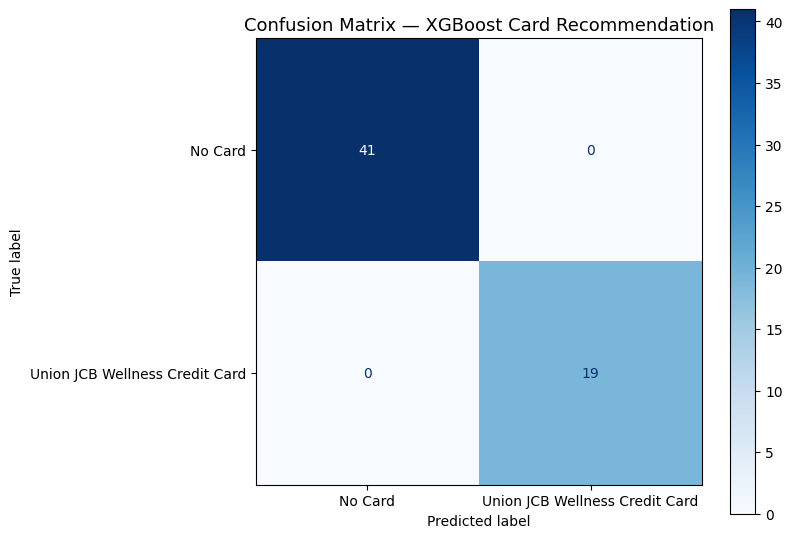

Saved: confusion_matrix.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.title('Confusion Matrix — XGBoost Card Recommendation', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

## 9. Feature Importance

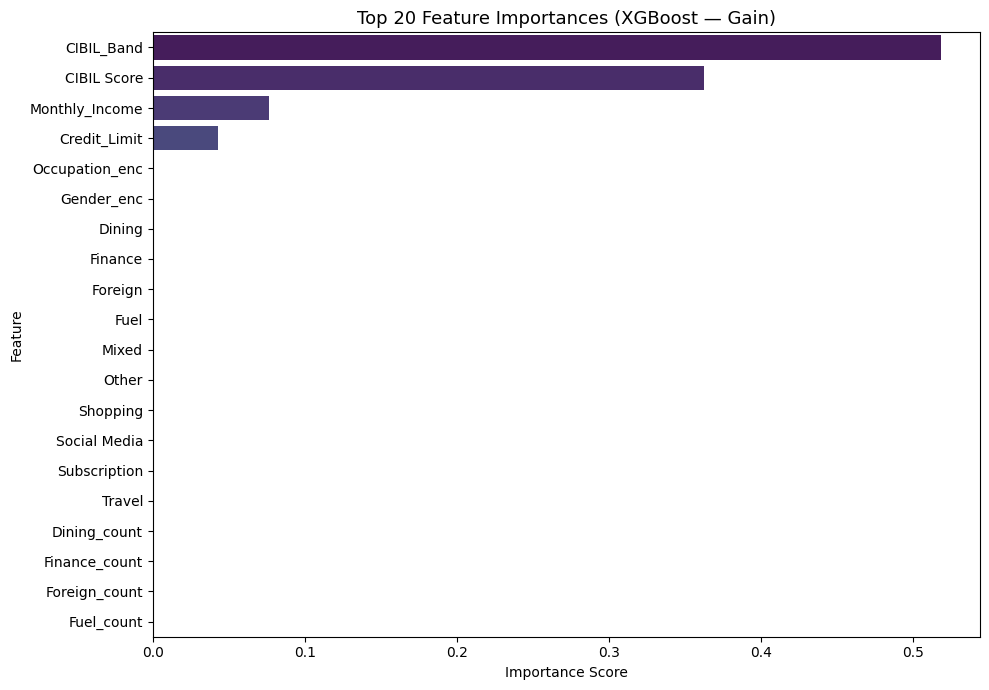

Saved: feature_importance.png

       Feature  Importance
    CIBIL_Band    0.518036
   CIBIL Score    0.362283
Monthly_Income    0.076650
  Credit_Limit    0.043030
Occupation_enc    0.000000
    Gender_enc    0.000000
        Dining    0.000000
       Finance    0.000000
       Foreign    0.000000
          Fuel    0.000000
         Mixed    0.000000
         Other    0.000000
      Shopping    0.000000
  Social Media    0.000000
  Subscription    0.000000
        Travel    0.000000
  Dining_count    0.000000
 Finance_count    0.000000
 Foreign_count    0.000000
    Fuel_count    0.000000


In [12]:
importance_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, y='Feature', x='Importance', palette='viridis')
plt.title('Top 20 Feature Importances (XGBoost — Gain)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Saved: feature_importance.png")
print()
print(importance_df.to_string(index=False))

## 10. Generate Recommendations & Export

In [13]:
# Full-dataset predictions using the trained XGBoost model
data['XGB_Primary_Card'] = le_target.inverse_transform(model.predict(X))

# Build output records — include rule-based list + XGBoost primary prediction
output = []
for _, row in data.iterrows():
    output.append({
        'Full Name':         row['Full Name'],
        'Account Number':    int(row['Account Number']),
        'CIBIL Score':       int(row['CIBIL Score']),
        'Monthly_Income':    round(float(row['Monthly_Income']), 2),
        'Credit_Limit':      round(float(row['Credit_Limit']), 2),
        'Recommended_Cards': row['Recommended_Cards'],  # all eligible cards (rule-based)
        'XGB_Primary_Card':  row['XGB_Primary_Card'],   # ML model top pick
    })

# Save JSON
with open('recommendations_xgb.json', 'w') as f:
    json.dump(output, f, indent=4)

# Save CSV
data[['Full Name','Account Number','CIBIL Score','Monthly_Income',
      'Credit_Limit','Primary_Card','XGB_Primary_Card']].to_csv('recommendations_xgb.csv', index=False)

print(f"Saved {len(output)} recommendations.")
print()
print("Sample output (first 5):")
print(json.dumps(output[:5], indent=2))

Saved 300 recommendations.

Sample output (first 5):
[
  {
    "Full Name": "Renee Dayal",
    "Account Number": 794843871722,
    "CIBIL Score": 367,
    "Monthly_Income": 26829.83,
    "Credit_Limit": 26829.83,
    "Recommended_Cards": [
      "No Card"
    ],
    "XGB_Primary_Card": "No Card"
  },
  {
    "Full Name": "Bhavin Toor",
    "Account Number": 963450436285,
    "CIBIL Score": 601,
    "Monthly_Income": 72596.25,
    "Credit_Limit": 145192.5,
    "Recommended_Cards": [
      "No Card"
    ],
    "XGB_Primary_Card": "No Card"
  },
  {
    "Full Name": "Nitara Venkataraman",
    "Account Number": 314939397126,
    "CIBIL Score": 678,
    "Monthly_Income": 27661.0,
    "Credit_Limit": 55322.0,
    "Recommended_Cards": [
      "No Card"
    ],
    "XGB_Primary_Card": "No Card"
  },
  {
    "Full Name": "Purab Lata",
    "Account Number": 269085222633,
    "CIBIL Score": 427,
    "Monthly_Income": 134534.5,
    "Credit_Limit": 134534.5,
    "Recommended_Cards": [
      "No Card

## 11. Predict for a New Customer

Use this cell to get an instant card recommendation for any new customer profile.